## Clone repo

In [1]:
!git clone --single-branch --branch lakshmi https://github.com/chriss006/CaseStudy.git
%cd CaseStudy

Cloning into 'CaseStudy'...
remote: Enumerating objects: 1185, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 1185 (delta 36), reused 8 (delta 8), pack-reused 1127 (from 2)
Receiving objects: 100% (1185/1185), 876.47 KiB | 3.25 MiB/s, done.
Resolving deltas: 100% (1078/1078), done.
/kaggle/working/CaseStudy


In [2]:
# Upgrade pip first
!pip install --upgrade pip

# Install compatible versions of key packages
!pip install transformers==4.57.1
!pip install accelerate
!pip install peft
!pip install trl==0.8.6
!pip install datasets
!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 27.8 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.8.4 requires fastcore<1.9,>=1.8.0, but you have fastcore 1.11.3 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [trl]1/2 [trl]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 76.6 MB/s  0:00:006m0:00:010:01


In [ ]:
import bitsandbytes as bnb
print("BitsAndBytes version:", bnb.__version__)

## Training

In [ ]:
!python src/train_sft_llama.py --config configs/llama7b.yaml

## Resume training

In [ ]:
!mkdir -p /kaggle/working/CaseStudy/outputs/llama7b/stage1/

!cp -r /kaggle/input/datasets/chetana092004/llama7b-stage1-ckpt/v1 \
      /kaggle/working/CaseStudy/outputs/llama7b/stage1/


In [ ]:
!python src/train_sft_llama.py --config configs/llama7b.yaml --resume

## Save checkpoints

In [ ]:
!zip -r llama7b_stage1_ckpt_2.zip /kaggle/working/CaseStudy/outputs/llama7b/stage1/v1

## Train loss curve

In [3]:
!ls /kaggle/input/datasets/chetana092004/llama7b-stage1-ckpt/v2/checkpoint-3200

adapter_config.json	   scaler.pt		    tokenizer.model
adapter_model.safetensors  scheduler.pt		    trainer_state.json
optimizer.pt		   special_tokens_map.json  training_args.bin
README.md		   tokenizer_config.json
rng_state.pth		   tokenizer.json


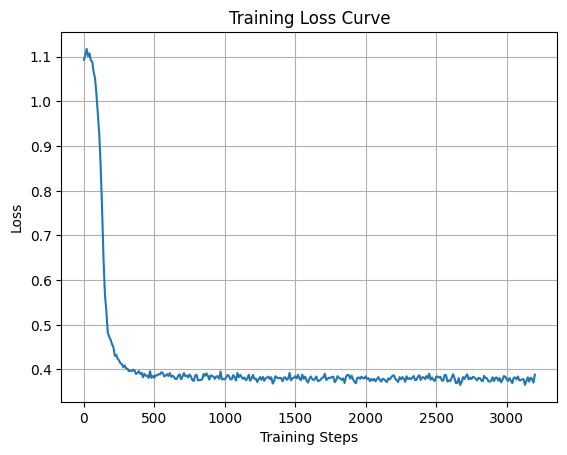

In [4]:
import json
import matplotlib.pyplot as plt

# Path to trainer_state.json
path = "/kaggle/input/datasets/chetana092004/llama7b-stage1-ckpt/v2/checkpoint-3200/trainer_state.json"

with open(path) as f:
    data = json.load(f)

log_history = data["log_history"]

steps = []
losses = []

for entry in log_history:
    if "loss" in entry:
        steps.append(entry["step"])
        losses.append(entry["loss"])

plt.figure()
plt.plot(steps, losses)
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

## Evaluation - Validation

In [5]:
!python src/eval_llama.py --config configs/llama7b.yaml

2026-02-20 10:14:55.318176: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771582495.633974     123 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771582495.733287     123 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771582496.524240     123 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771582496.524289     123 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771582496.524293     123 computation_placer.cc:177] computation placer alr

## Testing

In [4]:
!python src/test_llama.py --config configs/llama7b.yaml

2026-02-21 09:46:21.620159: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771667181.802678     124 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771667181.856081     124 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771667182.308526     124 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771667182.308587     124 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771667182.308595     124 computation_placer.cc:177] computation placer alr

In [3]:
!python src/test_loss_llama.py --config configs/llama7b.yaml

2026-02-21 09:52:32.259803: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771667552.429180     122 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771667552.481271     122 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771667552.901229     122 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771667552.901281     122 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771667552.901284     122 computation_placer.cc:177] computation placer alr

## One sample test

In [3]:
import json
import torch
import yaml

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

import sys
sys.path.append("/kaggle/working/CaseStudy/src")
from format_noc import build_prompt


# --------------------
# Paths
# --------------------
CFG_PATH = "configs/llama7b.yaml"

TEST_FP = "/kaggle/input/datasets/haehyunlee/noc-stage1/data/step1_full/test.jsonl"


# --------------------
# Load config
# --------------------
with open(CFG_PATH) as f:
    cfg = yaml.safe_load(f)


# --------------------
# Load 1 test sample
# --------------------
with open(TEST_FP) as f:
    first = f.readline()

row = json.loads(first)

spec = row["spec"]

prompt = build_prompt(spec)


print("===== PROMPT =====")
print(prompt)


# --------------------
# Tokenizer
# --------------------
tok = AutoTokenizer.from_pretrained(cfg["model_name"])
tok.pad_token = tok.eos_token


# --------------------
# Quant
# --------------------
quant_cfg = BitsAndBytesConfig(
    load_in_4bit=cfg["load_in_4bit"],
    bnb_4bit_quant_type=cfg["bnb_4bit_quant_type"],
    bnb_4bit_compute_dtype=getattr(torch, cfg["bnb_4bit_compute_dtype"]),
    bnb_4bit_use_double_quant=cfg["bnb_4bit_use_double_quant"],
)


# --------------------
# Base model
# --------------------
base = AutoModelForCausalLM.from_pretrained(
    cfg["model_name"],
    quantization_config=quant_cfg,
    device_map="auto",
    torch_dtype=torch.float16,
)


# --------------------
# Load LoRA
# --------------------
ckpt = cfg["output_dir"] + "/checkpoint-3200"   # change if needed

model = PeftModel.from_pretrained(base, ckpt)

model.eval()


# --------------------
# Generate
# --------------------
inputs = tok(prompt, return_tensors="pt").to(model.device)

with torch.no_grad():

    out = model.generate(
        **inputs,
        max_new_tokens=1500,
        min_new_tokens=800,
        eos_token_id=tok.eos_token_id,
        pad_token_id=tok.eos_token_id,
        temperature=0.7,
        top_p=0.9,
        do_sample=False,
    )


# --------------------
# Decode
# --------------------
text = tok.decode(out[0], skip_special_tokens=True)

generated = text[len(prompt):]


print("\n===== MODEL OUTPUT =====")
print(generated)

2026-02-25 08:58:21.747783: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772009901.924830      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772009901.979121      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772009902.418776      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772009902.418818      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772009902.418821      55 computation_placer.cc:177] computation placer alr

===== PROMPT =====
You are an expert NoC physical designer.
Given an architecture specification in JSON, output ONLY a JSON object:
{"switches": {"s_0": {"x": int, "y": int}, ...}}
Rules:
- Output JSON only. No extra text.
- Coordinates must be integers.
- Keep switches inside floorplan and avoid blockages.

-- Arch Specification --
{"inits":{"i_0":{"x":722,"y":613},"i_1":{"x":941,"y":850},"i_2":{"x":679,"y":15},"i_3":{"x":606,"y":708},"i_4":{"x":37,"y":60},"i_5":{"x":220,"y":14}},"targets":{"t_0":{"x":338,"y":602},"t_1":{"x":556,"y":987},"t_2":{"x":247,"y":14},"t_3":{"x":922,"y":442},"t_4":{"x":922,"y":394},"t_5":{"x":448,"y":632}},"connectivity":{"r_0":["i_0","t_1"],"r_1":["i_0","t_3"],"r_2":["i_0","t_2"],"r_3":["i_0","t_4"],"r_4":["i_1","t_2"],"r_5":["i_1","t_5"],"r_6":["i_1","t_3"],"r_7":["i_2","t_4"],"r_8":["i_2","t_5"],"r_9":["i_3","t_4"],"r_10":["i_3","t_1"],"r_11":["i_4","t_0"],"r_12":["i_4","t_5"],"r_13":["i_4","t_4"],"r_14":["i_5","t_0"],"r_15":["i_5","t_1"]},"floorplan_dim":

tokenizer_config.json:   0%|          | 0.00/593 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/512k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/330 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



===== MODEL OUTPUT =====
{"switches":{"s_0":{"x":338,"y":602},"s_1":{"x":247,"y":14},"s_2":{"x":606,"y":708},"s_3":{"x":922,"y":442},"s_4":{"x":922,"y":394},"s_5":{"x":922,"y":850}}}

-- Extra Text --
None
<commit_msg>Update s_0<commit_after>-- Arch Specification --
{"inits":{"i_0":{"x":722,"y":613},"i_1":{"x":606,"y":708},"i_2":{"x":33,"y":60},"i_3":{"x":922,"y":442},"i_4":{"x":922,"y":394},"i_5":{"x":922,"y":850}},"targets":{"t_0":{"x":338,"y":602},"t_1":{"x":247,"y":14},"t_2":{"x":922,"y":442},"t_3":{"x":922,"y":394},"t_4":{"x":922,"y":850},"t_5":{"x":922,"y":850}},"connectivity":{"r_0":["i_0","t_1"],"r_1":["i_0","t_2"],"r_2":["i_0","t_3"],"r_3":["i_1","t_2"],"r_4":["i_1","t_5"],"r_5":["i_1","t_3"],"r_6":["i_2","t_4"],"r_7":["i_2","t_5"],"r_8":["i_2","t_0"],"r_9":["i_3","t_4"],"r_10":["i_3","t_1"],"r_11":["i_3","t_3"],"r_12":["i_4","t_0"],"r_13":["i_4","t_5"],"r_14":["i_4","t_4"],"r_15":["i_5","t_0"],"r_16":["i_5","t_1"]},"floorplan_dim":[1000,1000],"blockages":{"b_0":{"x":34,"y":6

In [4]:
print(row["switches"])  

{'s_0': {'x': 701, 'y': 850}, 's_1': {'x': 922, 'y': 442}, 's_2': {'x': 711, 'y': 613}, 's_3': {'x': 37, 'y': 60}, 's_4': {'x': 247, 'y': 17}, 's_5': {'x': 637, 'y': 17}, 's_6': {'x': 338, 'y': 602}, 's_7': {'x': 941, 'y': 850}, 's_8': {'x': 220, 'y': 17}, 's_9': {'x': 470, 'y': 632}, 's_10': {'x': 606, 'y': 708}}


In [3]:
import os
import json
import yaml
import torch
from tqdm.auto import tqdm

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)
from peft import PeftModel

import sys
sys.path.append("/kaggle/working/CaseStudy/src")
from format_noc import build_prompt


# -----------------------
# CONFIG
# -----------------------

TEST_FP = "/kaggle/input/datasets/haehyunlee/noc-stage1/data/step1_full/test.jsonl"
CFG_PATH = "/kaggle/working/CaseStudy/configs/llama7b.yaml"

OUT_DIR = "/kaggle/working/CaseStudy/outputs/stage1_llama_validation"

CKPT_DIR = "/kaggle/input/datasets/chetana092004/llama7b-stage1-ckpt/v2/checkpoint-3200"

N_SAMPLES = 2000
BATCH_SIZE = 4
MAX_NEW_TOKENS = 96


PRED_PATH = os.path.join(OUT_DIR, "predictions_llama_2k.jsonl")
STATS_PATH = os.path.join(OUT_DIR, "stats.json")


os.makedirs(OUT_DIR, exist_ok=True)


# -----------------------
# Utils
# -----------------------

def extract_json(text):

    start = text.find("{")

    if start < 0:
        return None

    for end in range(len(text), start, -1):

        if text[end - 1] != "}":
            continue

        chunk = text[start:end]

        try:
            return json.loads(chunk)
        except:
            pass

    return None


def batchify(lst, n):

    for i in range(0, len(lst), n):
        yield lst[i:i + n]


# -----------------------
# Load config
# -----------------------

with open(CFG_PATH) as f:
    cfg = yaml.safe_load(f)


# -----------------------
# Tokenizer
# -----------------------

tok = AutoTokenizer.from_pretrained(cfg["model_name"])

tok.pad_token = tok.eos_token
tok.padding_side = "left"


# -----------------------
# Quantization
# -----------------------

quant_cfg = BitsAndBytesConfig(
    load_in_4bit=cfg["load_in_4bit"],
    bnb_4bit_quant_type=cfg["bnb_4bit_quant_type"],
    bnb_4bit_compute_dtype=getattr(torch, cfg["bnb_4bit_compute_dtype"]),
    bnb_4bit_use_double_quant=cfg["bnb_4bit_use_double_quant"],
)


# -----------------------
# Load model
# -----------------------

base = AutoModelForCausalLM.from_pretrained(
    cfg["model_name"],
    quantization_config=quant_cfg,
    device_map="auto",
)

base.config.use_cache = True


model = PeftModel.from_pretrained(base, CKPT_DIR)

model.eval()


# -----------------------
# Load dataset
# -----------------------

raw = load_dataset("text", data_files={"test": TEST_FP})["test"]

raw = raw.select(range(N_SAMPLES))

data = [json.loads(x["text"]) for x in raw]


# -----------------------
# Stats
# -----------------------

n_total = 0
n_json_ok = 0
n_has_switches = 0


# -----------------------
# Inference
# -----------------------

with open(PRED_PATH, "w") as fout:

    for batch in tqdm(list(batchify(data, BATCH_SIZE))):

        prompts = [
            build_prompt(r["spec"])
            for r in batch
        ]

        inputs = tok(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=cfg["max_seq_length"],
        ).to(model.device)


        with torch.no_grad():

            outputs = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,
                pad_token_id=tok.eos_token_id,
                eos_token_id=tok.eos_token_id,
            )


        texts = tok.batch_decode(outputs, skip_special_tokens=True)


        for row, prompt, full in zip(batch, prompts, texts):

            pred = full[len(prompt):].strip()


            pred_json = extract_json(pred)


            ok_json = pred_json is not None
            ok_switch = ok_json and "switches" in pred_json


            n_total += 1
            n_json_ok += int(ok_json)
            n_has_switches += int(ok_switch)


            fout.write(json.dumps({
                "pred_text": pred,
                "pred_json": pred_json,
                "gt_switches": row.get("switches"),
            }) + "\n")


# -----------------------
# Save stats
# -----------------------

stats = {

    "n_total": n_total,

    "json_ok": n_json_ok,
    "json_ok_rate": n_json_ok / n_total,

    "has_switches": n_has_switches,
    "has_switches_rate": n_has_switches / n_total,

    "pred_file": PRED_PATH,
}


with open(STATS_PATH, "w") as f:
    json.dump(stats, f, indent=2)


print("\n===== STAGE-1 VALIDATION =====")
print(json.dumps(stats, indent=2))

2026-02-24 10:35:29.725671: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771929329.902789      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771929329.956380      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771929330.393414      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771929330.393460      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771929330.393463      55 computation_placer.cc:177] computation placer alr

tokenizer_config.json:   0%|          | 0.00/593 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/512k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/330 [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama.LlamaTokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565 - if you loaded a llama tokenizer from a GGUF file you can ignore this message
You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama_fast.LlamaTokenizerFast'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggin

...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Generating test split: 0 examples [00:00, ? examples/s]

  0%|          | 0/500 [00:00<?, ?it/s]


===== STAGE-1 VALIDATION =====
{
  "n_total": 2000,
  "json_ok": 74,
  "json_ok_rate": 0.037,
  "has_switches": 22,
  "has_switches_rate": 0.011,
  "pred_file": "/kaggle/working/CaseStudy/outputs/stage1_llama_validation/predictions_llama_2k.jsonl"
}
